In [5]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from sklearn.preprocessing import StandardScaler

In [2]:
from matplotlib import rc
import matplotlib as mpl
rc('font',**{'family':'libertine'})
rc('text', usetex=True)
# rc('pgf', texsystem='pdflatex', rcfonts=False)
rc('text.latex', preamble=r'\usepackage{scalerel,stackengine,amsmath,amsfonts}')

FIGURES_PATH = '../../../Dropbox/Програми/Overleaf/Frequentist Consistency of (causal) PFNs (ICML)/figures/'

In [3]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import seaborn as sns
import pandas as pd

sample_name = r"Amount of measured confounding, $\Delta$"
dim_cov_name = r"$d_x$"

Simpsons parasox measure (features = 5): 0.04142536595463753


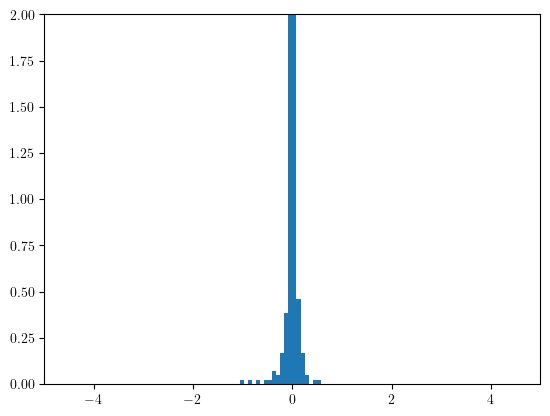

Simpsons parasox measure (features = 50): 0.036605823785066605


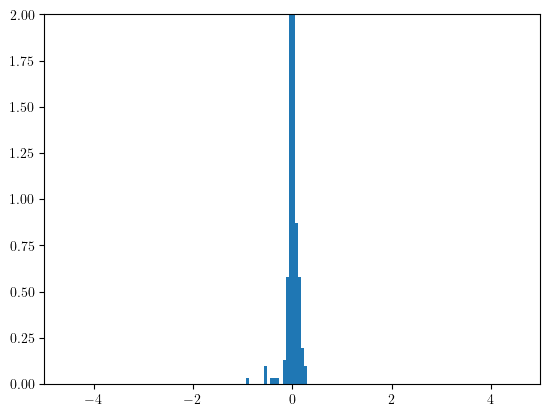

Simpsons parasox measure (features = 100): 0.031082477420568466


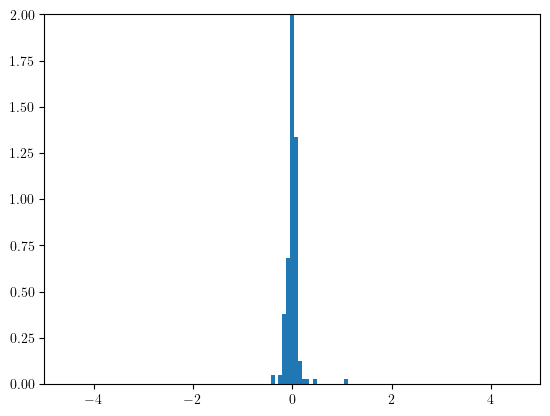

In [12]:
dfs = []
num_features_list = [5, 50, 100]

for num_features in num_features_list:

    data = torch.load(f'synthetic_backdoor_dgp_xdim_{num_features}_nsamples_10000_ndataset_512.pt')
    
    A, Y0, Y1, Y = [], [], [], []
    for d in data:
        Y0.append(d['y0'])
        Y1.append(d['y1'])
        A.append(d['t'])
        Y.append(d['y1'] * (d['t'] == 1.0) + d['y0'] * (d['t'] == 0.0))
        
    
    Y0 = torch.stack(Y0, -1)
    Y1 = torch.stack(Y1, -1)
    A = torch.stack(A, -1)
    Y = torch.stack(Y, -1)

    
    
    ates = ((Y1 - Y0)/Y.std(0, keepdim=True)).mean(0)
    means_diff = ((A * Y/Y.std(0, keepdim=True)).sum(0) / A.sum(0)) - (((1.0 - A) * Y/Y.std(0, keepdim=True)).sum(0) / (1.0 - A).sum(0))
    
    # print("Average propensity:", PS.mean().item())

    difss = ates - means_diff 
    difss = difss[~difss.isnan()]
    difss = difss[(difss > -5.0) & (difss < 5.0)]
    
    print(f"Simpsons parasox measure (features = {num_features}):", (difss).abs().nanmean().item())
    plt.hist(difss, density=True, bins=20)
    plt.xlim(-5, 5)
    plt.ylim(0, 2.0)
    plt.show()
    
    dfs.append(pd.DataFrame({'sample': difss}))

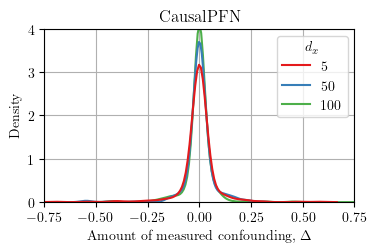

In [18]:
df = pd.concat(dfs, keys=num_features_list)
df = df.reset_index()

df = df.rename(columns={'sample': sample_name,  'level_0': dim_cov_name})

fig, ax = plt.subplots(figsize=(4, 2.25))
sns.kdeplot(df, x=sample_name, hue=dim_cov_name, palette='Set1', ax=ax)
plt.ylim(0.0, 4.0)
plt.xlim(-0.75, 0.75)
plt.grid()
plt.title('CausalPFN')

plt.savefig(f'{FIGURES_PATH}/causalpfn-bias.pdf', bbox_inches = 'tight', pad_inches = 0.1)